# Diabetes Prediction Using K-Nearest Neighbors (KNN)

## Objective

Predict whether a subject has diabetes using **K-Nearest Neighbors (KNN) classification**.

This notebook covers:

1. Exploratory data analysis
2. Data-quality checks
3. Train/test splitting
4. Feature standardization
5. KNN model development
6. Hyperparameter tuning with cross-validation
7. Evaluation using accuracy, precision, recall, F1-score, and confusion matrix
8. Comparison of KNN configurations
9. Model limitations and interpretation

> **Important:** This is an educational machine-learning project. It is not a medical diagnostic tool.


## Dataset

The analysis uses `Dataset_Diabetes_Prediction.csv`.

Expected columns:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`
- `Diagnosis`

Target:

- `0` = No Diabetes
- `1` = Diabetes


In [ ]:
# %pip install pandas numpy matplotlib seaborn scikit-learn jupyter joblib


  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached bleach-6.4.0-py3-none-any.whl.metadata (32 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.met

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
DATA_PATH = Path("../data/Dataset_Diabetes_Prediction.csv")

df = pd.read_csv(DATA_PATH)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


## 1. Understand the dataset

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.info())
display(df.describe().T)


Rows: 1,000
Columns: 9
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,1000.0,1.771000,1.354398,0.000000,1.000000,2.000000,3.000000,8.000000
Glucose,1000.0,99.440607,19.470730,30.571402,86.145927,99.458362,113.264556,161.238939
BloodPressure,1000.0,72.179837,13.882017,31.401487,62.795447,71.909588,82.082660,110.723715
SkinThickness,1000.0,23.278316,1.173807,19.369987,22.501591,23.275225,24.052022,26.917654
Insulin,1000.0,84.582679,74.872733,-165.310033,35.076535,84.442232,134.267842,317.701852
BMI,1000.0,25.433600,3.690223,13.548818,23.022715,25.455649,27.972184,36.324598
DiabetesPedigreeFunction,1000.0,0.449383,0.199334,0.100037,0.283376,0.448219,0.619158,0.799654
Age,1000.0,43.281798,14.465398,-0.979804,33.518451,43.634273,53.098446,90.573782
Diagnosis,1000.0,0.306000,0.461060,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagnosis']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64

Duplicate rows: 0


In [8]:
target_counts = df["Diagnosis"].value_counts().sort_index()
target_pct = df["Diagnosis"].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_pct.round(2))


Target counts:
Diagnosis
0    694
1    306
Name: count, dtype: int64

Target percentage:
Diagnosis
0    69.4
1    30.6
Name: proportion, dtype: float64


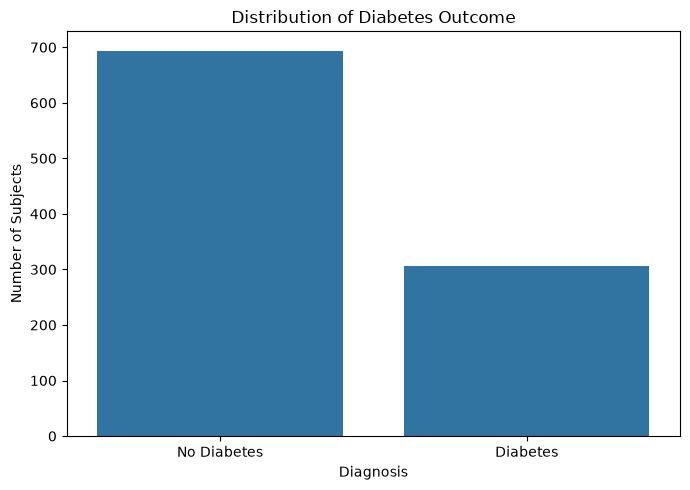

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Diagnosis")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Subjects")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.tight_layout()
plt.savefig("../reports/target_distribution.png", dpi=150)
plt.show()


## 2. Data-quality checks

The model expects numeric predictors. We also inspect the observed ranges before training.

A suspicious or implausible value should be investigated using the dataset's documentation or source context rather than automatically deleting it.


In [12]:
feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

target_column = "Diagnosis"

display(df[feature_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,1000.0,1.771000,1.354398,0.000000,1.000000,2.000000,3.000000,8.000000
Glucose,1000.0,99.440607,19.470730,30.571402,86.145927,99.458362,113.264556,161.238939
BloodPressure,1000.0,72.179837,13.882017,31.401487,62.795447,71.909588,82.082660,110.723715
SkinThickness,1000.0,23.278316,1.173807,19.369987,22.501591,23.275225,24.052022,26.917654
Insulin,1000.0,84.582679,74.872733,-165.310033,35.076535,84.442232,134.267842,317.701852
BMI,1000.0,25.433600,3.690223,13.548818,23.022715,25.455649,27.972184,36.324598
DiabetesPedigreeFunction,1000.0,0.449383,0.199334,0.100037,0.283376,0.448219,0.619158,0.799654
Age,1000.0,43.281798,14.465398,-0.979804,33.518451,43.634273,53.098446,90.573782


In [13]:
# Flag values that may require source-level investigation.
range_flags = pd.DataFrame({
    "negative_values": (df[feature_columns] < 0).sum(),
    "zero_values": (df[feature_columns] == 0).sum(),
})

display(range_flags)


,negative_values,zero_values
Pregnancies,0,185
Glucose,0,0
BloodPressure,0,0
SkinThickness,0,0
Insulin,127,0
BMI,0,0
DiabetesPedigreeFunction,0,0
Age,2,0


## 3. Separate predictors and target

In [14]:
X = df[feature_columns].copy()
y = df[target_column].copy()

print("Features:", X.columns.tolist())
print("Target:", y.name)


Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target: Diagnosis


## 4. Train/test split

An 80/20 split is used. `stratify=y` preserves the class proportions in both subsets.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 800
Testing observations: 200


## 5. Baseline KNN model

KNN is distance-based, so the predictors are standardized before classification.

The scaler is placed **inside the pipeline** so that preprocessing is learned only from the training folds during cross-validation.


In [16]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

baseline_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={"knn__n_neighbors": range(1, 31)},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
    n_jobs=-1,
)

baseline_grid.fit(X_train, y_train)

print("Best K by accuracy:", baseline_grid.best_params_["knn__n_neighbors"])
print("Best CV accuracy:", round(baseline_grid.best_score_, 4))


Best K by accuracy: 8
Best CV accuracy: 0.6962


In [17]:
best_baseline = baseline_grid.best_estimator_
baseline_pred = best_baseline.predict(X_test)

print(classification_report(
    y_test,
    baseline_pred,
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
))


              precision    recall  f1-score   support

 No Diabetes       0.68      0.92      0.79       139
    Diabetes       0.15      0.03      0.05        61

    accuracy                           0.65       200
   macro avg       0.42      0.48      0.42       200
weighted avg       0.52      0.65      0.56       200



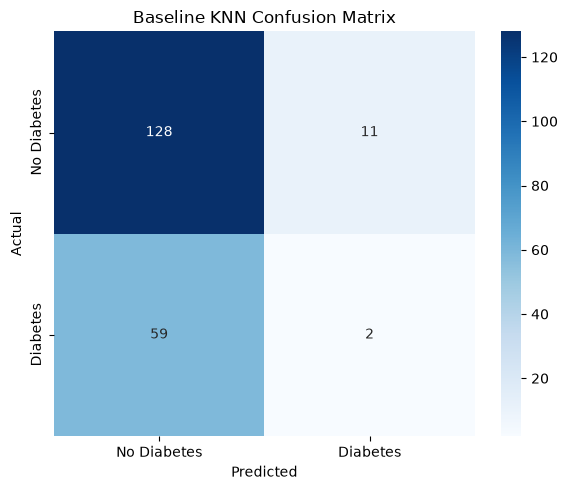

In [19]:
baseline_cm = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.title("Baseline KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../reports/baseline_confusion_matrix.png", dpi=150)
plt.show()


## 6. Why accuracy alone is not enough

The diabetes class is the positive class. A model can achieve reasonable accuracy by mostly predicting the majority class.

For this reason, we compare:

- Accuracy
- Precision
- Recall
- F1-score

For this project, **recall for the Diabetes class** is especially important to inspect because it measures how many actual diabetes cases were identified by the model.


## 7. Tune KNN for the diabetes class

Instead of selecting K using accuracy alone, we perform a second search using **F1-score for the Diabetes class**.

We also compare uniform and distance-based KNN weighting.


In [20]:
f1_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    param_grid={
        "knn__n_neighbors": range(1, 31),
        "knn__weights": ["uniform", "distance"],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
)

f1_grid.fit(X_train, y_train)

print("Best parameters:", f1_grid.best_params_)
print("Best CV diabetes F1:", round(f1_grid.best_score_, 4))


Best parameters: {'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Best CV diabetes F1: 0.3412


In [21]:
improved_knn = f1_grid.best_estimator_
improved_pred = improved_knn.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, improved_pred),
    "Precision": precision_score(y_test, improved_pred, zero_division=0),
    "Recall": recall_score(y_test, improved_pred, zero_division=0),
    "F1": f1_score(y_test, improved_pred, zero_division=0),
}

pd.Series(metrics).round(4)


Accuracy     0.5850
Precision    0.2963
Recall       0.2623
F1           0.2783
dtype: float64

              precision    recall  f1-score   support

 No Diabetes       0.69      0.73      0.71       139
    Diabetes       0.30      0.26      0.28        61

    accuracy                           0.58       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.57      0.58      0.58       200



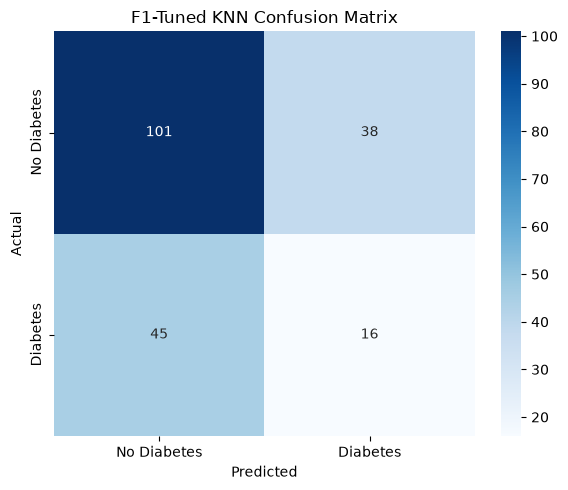

In [23]:
print(classification_report(
    y_test,
    improved_pred,
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
))

improved_cm = confusion_matrix(y_test, improved_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    improved_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.title("F1-Tuned KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../reports/improved_confusion_matrix.png", dpi=150)
plt.show()


## 8. Compare K values

The chart below shows the cross-validation performance across candidate K values for the original accuracy-based search.


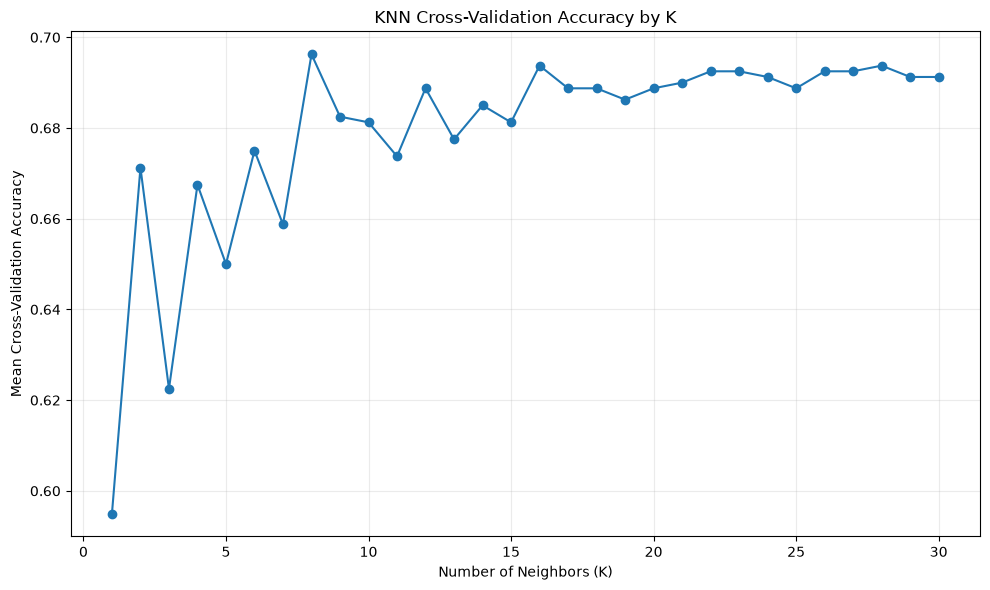

In [25]:
cv_results = pd.DataFrame(baseline_grid.cv_results_)
cv_results["K"] = cv_results["param_knn__n_neighbors"].astype(int)

plt.figure(figsize=(10, 6))
plt.plot(cv_results["K"], cv_results["mean_test_score"], marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("KNN Cross-Validation Accuracy by K")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("../reports/knn_accuracy_by_k.png", dpi=150)
plt.show()


## 9. Final comparison

In [26]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline KNN",
        "K": baseline_grid.best_params_["knn__n_neighbors"],
        "Accuracy": accuracy_score(y_test, baseline_pred),
        "Precision": precision_score(y_test, baseline_pred, zero_division=0),
        "Recall": recall_score(y_test, baseline_pred, zero_division=0),
        "F1": f1_score(y_test, baseline_pred, zero_division=0),
    },
    {
        "Model": "F1-Tuned KNN",
        "K": f1_grid.best_params_["knn__n_neighbors"],
        "Accuracy": accuracy_score(y_test, improved_pred),
        "Precision": precision_score(y_test, improved_pred, zero_division=0),
        "Recall": recall_score(y_test, improved_pred, zero_division=0),
        "F1": f1_score(y_test, improved_pred, zero_division=0),
    },
])

comparison.round(4)


,Model,K,Accuracy,Precision,Recall,F1
0,Baseline KNN,8,0.650,0.1538,0.0328,0.0541
1,F1-Tuned KNN,1,0.585,0.2963,0.2623,0.2783


## 10. Interpretation

The baseline model should not be judged by accuracy alone. If the model has poor recall for the Diabetes class, it is not adequately identifying positive cases.

The F1-tuned model provides a second perspective by explicitly optimizing the balance between precision and recall for the positive class.

Neither model should be interpreted as a medical diagnostic system. The dataset, feature definitions, sampling process, and clinical validity would need to be established before real-world use.


## 11. Reproducibility

The project uses:

- `random_state=42` for reproducible train/test splitting
- a scikit-learn `Pipeline` for leakage-safe scaling
- stratified cross-validation
- explicit model-selection metrics
- saved figures under `reports/figures/`

The reusable training script is available at `src/train_model.py`.
